In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit # for fit predict

In [ ]:
# Constants used in the model
# Author: Jesse
# Edit: Dimitar

g = 9.81  # m/s^2
r = 0.015  # radius of sphere (m)
rho_s = 1200  # density of sphere (kg/m^3)
rho_f = 1000  # density of fluid (kg/m^3)
eta0 = 1*10**-3  # reference viscosity (Pa·s) // viscosity of water as a reference point
A = 3000  # temperature constant (K)
T = np.linspace(293.15, 333.15, 100)  # 20°C to 60°C in K

eta = eta0 * np.exp(A / T)    # viscosity formula (literature) // Viscosity as function of temperature
# This formula is an approximation based on the hypothesized exponential relation between viscosity and temperature.


R = 8.314  # J/(mol K) // ideal gas const


In [ ]:
# Functions used in the model
# Author: Jesse
# Edit: Dimitar

# Terminal velocity from Stokes' law
# This is the formula that relates the observed terminal velocity to viscosity of the fluid

def terminal_velocity(r, rho_s, rho_f, eta):
    """
    r      : sphere radius (m)
    rho_s  : sphere density (kg/m^3)
    rho_f  : fluid density (kg/m^3)
    eta    : viscosity (Pa·s)
    """

    return (2 * r**2 * (rho_s - rho_f) * g) / (9 * eta)


# Arrhenius viscosity model
def viscosity_arrhenius(T, A, Ea):
    """
    Arrhenius-type viscosity model

    T  : temperature in Kelvin
    A  : pre-exponential factor (Pa*s)
    Ea : activation energy (J/mol)
    """

    return A * np.exp(Ea / (R * T))


def forceCheck():
  Fg = rho_s * ((4/3)*np.pi*(r**3)) * g     # gravitational force
  Fb = rho_f * ((4/3)*np.pi*(r**3))         # buoyancy force
  Fd = 6 * np.pi * eta * r * terminal_velocity
  return Fg < Fb


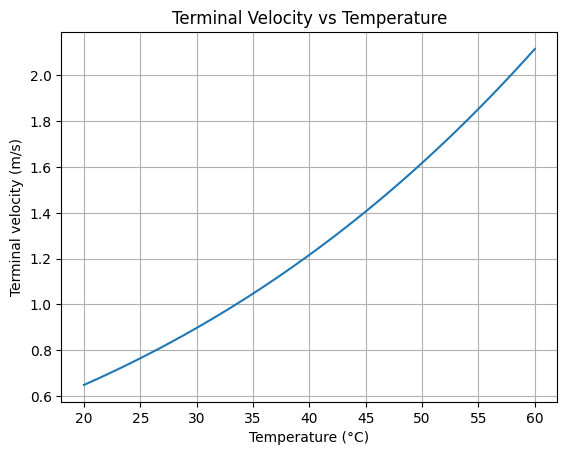

In [ ]:
# Author: Jesse

# This generates the array of terminal velocities
v = terminal_velocity(r, rho_s, rho_f, eta)


# Plot
plt.figure()
plt.plot(T - 273.15, v)
plt.xlabel("Temperature (°C)")
plt.ylabel("Terminal velocity (m/s)")
plt.title("Terminal Velocity vs Temperature")
plt.grid()
plt.savefig("Terminal_Velocity_vs_Temp_Water.pdf", dpi = 300)

plt.show()

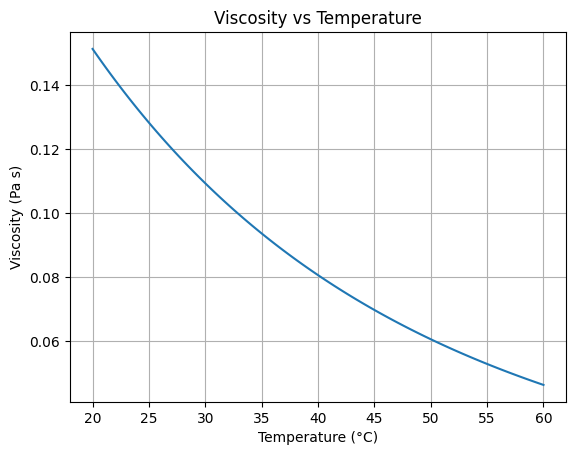

In [ ]:
# Author: Jesse
# Graphing the viscosity-temperature relationship

plt.figure()
plt.plot(T - 273.15, eta)
plt.xlabel("Temperature (°C)")
plt.ylabel("Viscosity (Pa s)")
plt.title("Viscosity vs Temperature")
plt.grid()
plt.savefig("Viscosity_vs_Temp_Water.pdf", dpi = 300)

plt.show()

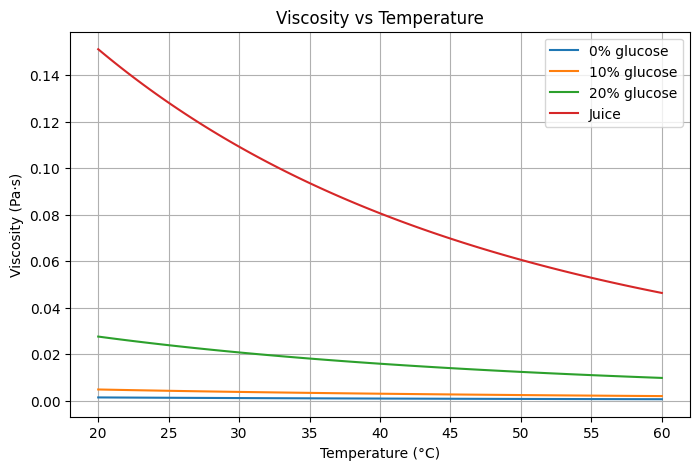

In [ ]:
# Example parameters
# (not exact literature values)
# Higher glucose concentration:
# -> larger Ea
# -> larger viscosity

fluids = {
    "0% glucose":  {"A": 2e-6, "Ea": 16000},
    "10% glucose": {"A": 3e-6, "Ea": 18000},
    "20% glucose": {"A": 5e-6, "Ea": 21000},
    "Juice":       {"A": 8e-6, "Ea": 24000},
}

# Plot viscosity vs temperature

plt.figure(figsize=(8,5))

for name, params in fluids.items():

    eta = viscosity_arrhenius(
        T,
        params["A"],
        params["Ea"]
    )

    plt.plot(T -273.15, eta, label=name)

plt.xlabel("Temperature (°C)")
plt.ylabel("Viscosity (Pa·s)")
plt.title("Viscosity vs Temperature")
plt.grid()
plt.legend()
plt.savefig("Arrhenius_Viscosity_vs_Temp.pdf", dpi = 300)

plt.show()


0% glucose
Estimated Ea = 16000.00 J/mol
Estimated A  = 2.00e-06 Pa·s

10% glucose
Estimated Ea = 18000.00 J/mol
Estimated A  = 3.00e-06 Pa·s

20% glucose
Estimated Ea = 21000.00 J/mol
Estimated A  = 5.00e-06 Pa·s

Juice
Estimated Ea = 24000.00 J/mol
Estimated A  = 8.00e-06 Pa·s


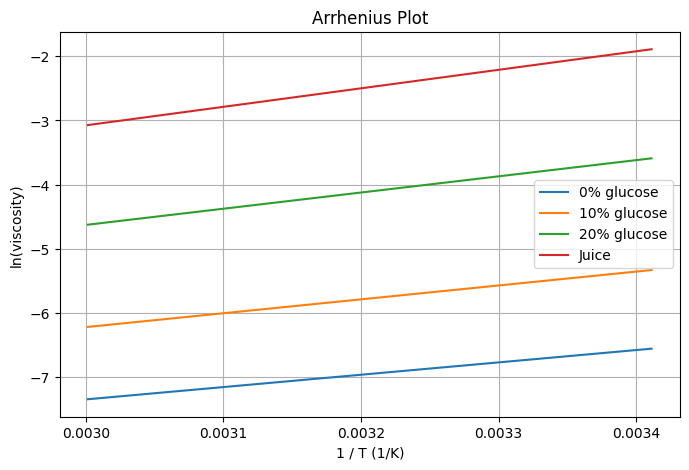

In [ ]:
# Arrhenius linearization: making the plot linear to calculate pre-exponential factor (A) and activation energy (Ea)
# ln(eta) vs 1/T

plt.figure(figsize=(8,5))

for name, params in fluids.items():

    eta = viscosity_arrhenius(
        T,
        params["A"],
        params["Ea"]
    )

    x = 1 / T
    y = np.log(eta)

    # Linear fit
    slope, intercept = np.polyfit(x, y, 1)

    # Extract parameters
    Ea_fit = slope * R
    A_fit = np.exp(intercept)

    print(f"\n{name}")
    print(f"Estimated Ea = {Ea_fit:.2f} J/mol")
    print(f"Estimated A  = {A_fit:.2e} Pa·s")

    plt.plot(x, y, label=name)

plt.xlabel("1 / T (1/K)")
plt.ylabel("ln(viscosity)")
plt.title("Arrhenius Plot")
plt.grid()
plt.legend()

plt.show()

In [ ]:
# Disregard this cell (first attempt)
# HERE WE have first itteration
# Author: Jesse

# Constants
b_diam = 0.05
b_dens = 5000
g = 9.81
l_dens = [920, 1000, 1060, 1330, 1420] #[oil, water, dreft, syrup, honey]

# Measured data
v_term = []

# Plot variables
viscosity = []
x = np.linspace(1, 100, len(viscosity))

# Formula
for i in v_term:
    visc = b_diam**2/(18*i) * (b_dens-l_dens) * g

In [ ]:
def exponential_fit (T,eta_0,B,T_vf):
  '''To be used to fit Vogel-Fulcher-Tamann to our data.
  T is the temperature, eta_0, B and T_vf are the constants'''
  return eta_0 * np.exp(B/(T-T_vf))
popt, pcov = curve_fit(exponential_fit, Temperature, Viscosity)#'Temperature' is the array of temperatures that we set.
plt.plot(Temperature,exponential_fit(Temperature,popt[0],popt[1],popt[2]))#'Viscosity is the array of the viscosities that we calculate from the measured terminal velocity
plt.show() #Should be plotted alongside the scatter plot of our datapoints

NameError: name 'Temperature' is not defined